In [1]:
import os
import sys
from pathlib import Path

In [2]:
# set work_path where phare will be run
try: # notebooks has no __file__
    WORK_DIR  = Path(__file__).parent 
except NameError:
    WORK_DIR  = Path(os.getcwd()) 
PROJECT_DIR = Path(WORK_DIR).parent.parent.parent.parent.parent
work_path = str(WORK_DIR)

In [3]:
# set the PYTHONPATH
paths = [str(PROJECT_DIR/s) for s in ["", "build", "pyphare"]]
sys.path.extend(paths)
os.environ['PYTHONPATH'] = os.pathsep.join(paths) + os.pathsep + os.environ.get('PYTHONPATH', "")

In [4]:
# just for ouam, to remove for the PR
home = os.environ['HOME']
src_path = os.path.join(home, 'far/PHARE')
build_path = os.path.join(home, 'far/builds/release/close')

if 'PYTHONPATH' in os.environ:
    os.environ['PYTHONPATH'] += os.pathsep + os.path.join(src_path, "pyphare")
else:
    os.environ['PYTHONPATH'] = os.pathsep + os.path.join(src_path, "pyphare")
os.environ['PYTHONPATH'] += os.pathsep + build_path

sys.path.append(os.path.join(src_path, "pyphare"))

In [5]:
import subprocess
import pyphare
import matplotlib.pyplot as plt
from pyphare.pharesee.run import Run
from pyphare.core.operators import dot, cross, sqrt, modulus, grad
# from pyphare.core.ufuncs import gF, peakIds
import numpy as np
from numpy import polyfit

# The ion acoustic wave

## Real part of the angular frequency

The mode that we are dealing with is the only linear unmagnetized electrostatic mode at low frequency, that is the ion acoustic mode. For this mode, one defines the ion acoustic speed as
$$
c_s = \left( \frac{\gamma_e k_B T_e + \gamma_i k_B T_i}{m_i} \right)^{1/2}
$$
For isothermal electrons, one has $\gamma_e = 1$ and for 1-dimensional adiabatic ions, $\gamma_i = 3$.
Hence, the real part of the angular frequency simply writes
$$
\omega_r = k c_s
$$
We already checked that this is the velocity at which the weak perturbation is propagating. We retrieve this velocity easily in the calculation as the mode is non-dispersive, so each component of a wave packet is traveling at the same speed, hence all the mode in the initial gaussian fluctuation of $V_1$.

This mode is propagating under the approximation
$$
\left( \frac{k_B T_i}{m_i} \right)^{1/2} < \frac{\omega}{k} < \left( \frac{k_B T_e}{m_e} \right)^{1/2}
$$

The second inequality is always satisfied in the hybrid case as $m_e \to 0$. To satisfy the first one, we need to be in the case $T_i < T_e$.

In [6]:
run_name = 'real_isotherm'
run_path = os.path.join(work_path, run_name)

In [7]:
Ti = 0.02
Te = 0.1

gamma_e, gamma_i = 1, 3
cs = np.sqrt(gamma_e*Te+gamma_i*Ti)

In [8]:
files = []
if os.path.isdir(run_path):
    files = os.listdir(run_path)

In [9]:
import subprocess
if 'ions_charge_density.h5' not in files :
    os.chdir(work_path)
    subprocess.run(['mpirun', '-n', '2', 'python3', '-Ou', work_path+'/'+run_name+'.py', run_name, str(Te), str(Ti)], env=os.environ)

In [10]:
L = 160
k = 2*np.pi/L

In [11]:
# times = np.arange(0, 41, 2)  # for real part of omega
from pyphare.pharesee.hierarchy.fromh5 import get_times_from_h5
file = os.path.join(run_path, "ions_charge_density.h5")
times = get_times_from_h5(file)

In [12]:
run  = Run(run_path)

In [13]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

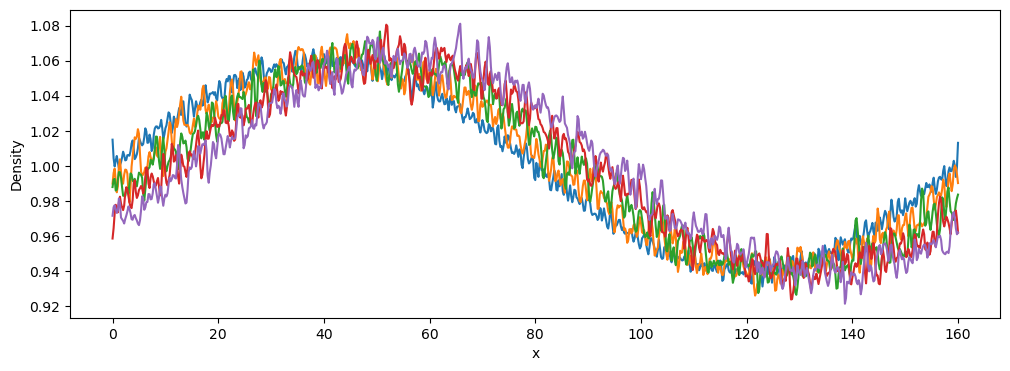

In [14]:
import pyphare.pharesee as phc

fig, ax = plt.subplots(figsize=(12, 4))

for i, time in enumerate(times[::5]):
    N = run.GetNi(time)
    n = phc.filters.gaussian(N, sigma=1)
    n.plot(qty='value', ax=ax, ls='solid', lw=2.0, color=colors[i%10], ylabel='Density')

In [15]:
from scipy.optimize import curve_fit

def sine_func(x, A, B, C):
    return A * np.sin(k * x + B) + C

def lin_func(x, A, B):
    return A * x + B

def exp_func(x, A, B, C):
    return A * np.exp(- B * x) + C

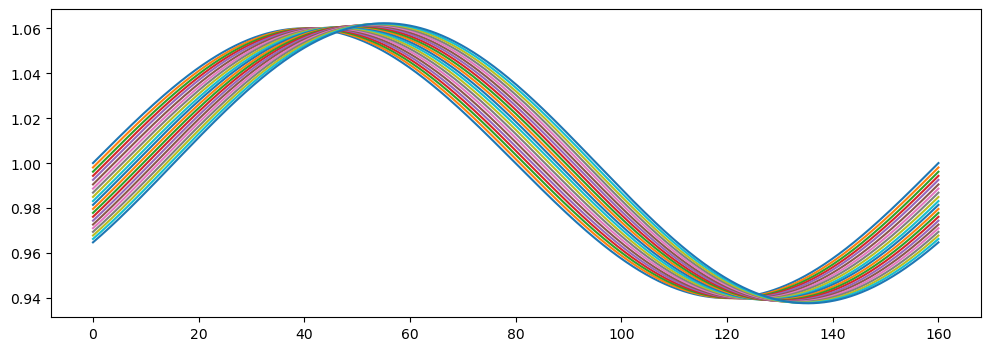

In [16]:
from pyphare.pharesee.hierarchy import uniformgrid as uniform

a1_far = np.zeros(times.shape)  # amplitude
f1_far = np.zeros(times.shape)  # phase

fig, ax = plt.subplots(figsize=(12, 4))

# For the IAW, these calculations can be done with charge density, longitudinal velocity or electric field
for i, time in enumerate(times):
    N = run.GetNi(time, all_primal=False)
    n = N.finest()
    data_on_uniform_grid = n
    # V = run.GetVi(time, all_primal=False)
    # v = V.finest()
    # data_on_uniform_grid = v['x']
    x_ = data_on_uniform_grid.x
    w_ = np.asarray(data_on_uniform_grid[:])

    params, covariance = curve_fit(sine_func, x_, w_, p0=[0.02, 0.0, 0.0])
 
    a1_far[i] = np.fabs(params[0])
    f1_far[i] = np.fabs(params[1])
    # # v.plot(qty='x', ax=ax, ls='solid', lw=2.0, color=colors[i%10], ylabel='X-velocity')
    ax.plot(x_, sine_func(x_, *params))

In [17]:
params, covariance = curve_fit(lin_func, times, f1_far, p0=[0.0125, 0.0])

In [18]:
vphi_num = params[0]/k
vphi_AI = cs

error = np.fabs(vphi_AI-vphi_num)/vphi_AI

print(f"analytical value for the IAW : {vphi_AI:.4f}")
print(f"numerical value for the IAW : {vphi_num:.4f}")
print(f"relative error : {100*error:.4f} %")

assert(error < 0.07)

analytical value for the IAW : 0.4000
numerical value for the IAW : 0.3834
relative error : 4.1403 %


Text(0, 0.5, '$\\varphi_0$')

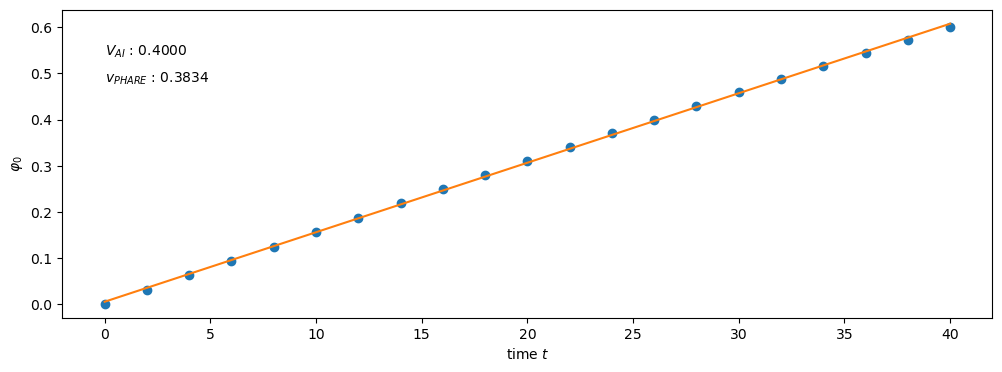

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(times, f1_far, lw=0, marker='o')
ax.plot(times, lin_func(times, *params))

ax.text(0, 0.9*f1_far[-1], r'$V_{{AI}}$ : {:.4f}'.format(vphi_AI))
ax.text(0, 0.8*f1_far[-1], r'$v_{{PHARE}}$ : {:.4f}'.format(vphi_num))

ax.set_xlabel('time $t$')
ax.set_ylabel(r'$\varphi_0$')

## Imaginary part of the angular frequency

But this ion acoustic mode is Landau damped, at a rate that we know. Its general form for a Maxwellian plasma is
$$
\gamma_L = \frac{- [\omega_r| \sqrt{\pi/8}}{(1+k^2 \lambda_{De}^2)^{3/2}} \left[ \left( \frac{T_e}{T_i} \right)^{3/2} \exp \left( - \frac{T_e/T_i}{2(1+k^2 \lambda_{De}^2)^{3/2}} + \sqrt{ \frac{m_e}{m_i} } \right) \right]
$$
This form is getting simpler in the hybrid case, that is $m_e/m_i \to 0$ and $\lambda_{De} \to 0$. Hence, this damping rate is simplifying as
$$
\gamma_L = - \sqrt{\frac{\pi}{8}} k c_s  \left( \frac{T_e}{T_i} \right)^{3/2} \exp \left[ - \frac{T_e}{2 T_i} \right]
$$

We know that we have to be in the case $T_e/T_i > 1$, but if this ratio is too large, the exponential term is driving the damping rate close to zero. We then decide to have $T_e = 0.2$ and $T_i = 0.1$.

Another precaution, is that to be as much as possible in the linear case, we take a density perturbation(sinusoidal) with an amplitude 0.06. The continuity equation in Fourier space gives
$$
-\imath \omega n_1 + \imath n_0 k V_1 = 0
$$
that is $V_1 = n_1 c_s$ for $n_0 = 1$. To be sure to pick up the right monochromatic ion acoustic mode, we then need to satisfy this polarisation in longitudinal velocity. While the mode is non-dispersive, this is important as the damping rate depends on the wave number $k$, so in a wave packet, each component would be damped at a different rate.

In [33]:
run_name = 'imag_isotherm_a'
run_path = os.path.join(work_path, run_name)

In [34]:
Ti = 0.1
Te = 0.2

gamma_e, gamma_i = 1, 3
cs = np.sqrt(gamma_e*Te+gamma_i*Ti)

In [35]:
files = []
if os.path.isdir(run_path):
    files = os.listdir(run_path)

In [36]:
import subprocess
if 'ions_charge_density.h5' not in files :
    os.chdir(work_path)
    subprocess.run(['mpirun', '-n', '2', 'python3', '-Ou', work_path+'/'+run_name+'.py', run_name, str(Te), str(Ti)], env=os.environ)

In [37]:
L = 40
k = 2*np.pi/L

In [38]:
# times = np.arange(0, 41, 2)  # for real part of omega
from pyphare.pharesee.hierarchy.fromh5 import get_times_from_h5
file = os.path.join(run_path, "ions_charge_density.h5")
times = get_times_from_h5(file)

In [39]:
run  = Run(run_path)

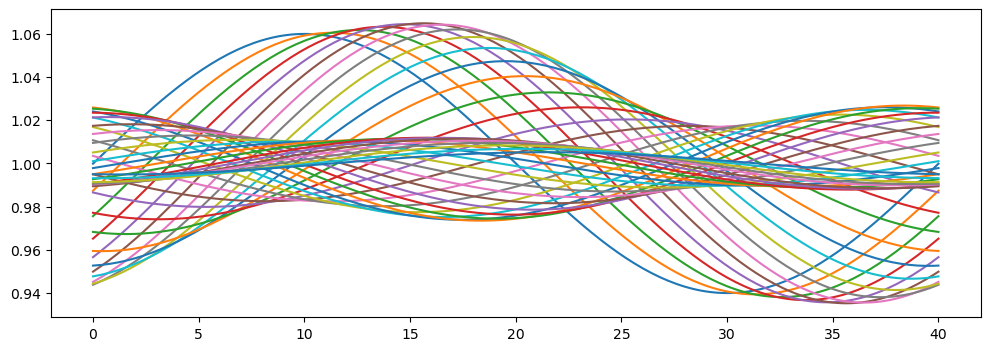

In [40]:
n1_far = np.zeros(times.shape)
f1_far = np.zeros(times.shape)

fig, ax = plt.subplots(figsize=(12, 4))

for i, time in enumerate(times):
    N = run.GetNi(time, all_primal=False)
    n = N.finest()
    data_on_uniform_grid = n
    # V = run.GetVi(time, all_primal=False)
    # v = V.finest()
    # data_on_uniform_grid = v['x']
    x_ = data_on_uniform_grid.x
    w_ = np.asarray(data_on_uniform_grid[:])

    params, covariance = curve_fit(sine_func, x_, w_, p0=[0.1, 0.0, 1.0])

    n1_far[i] = np.fabs(params[0])
    f1_far[i] = np.fabs(params[1])

    ax.plot(x_, sine_func(x_, *params))

In [57]:
z_ = np.gradient(n1_far)
first = np.argmax(z_ < 0)+1
last = first+np.argmax(z_[first:] > 0)
last = -1
# last=35

In [58]:
z_.shape

(41,)

In [59]:
params, covariance = curve_fit(exp_func, times[first:last], n1_far[first:last], p0=[0.04, 0.03, 0.0])

n1_fit = exp_func(times, *params)

In [60]:
gamma_num = params[1]
print("numerical fit  : {:.4f}".format(gamma_num))

gamma_landau = np.sqrt(np.pi/8) * k * cs * np.power(Te/Ti, 1.5) * np.exp(- 0.5*Te/Ti)
print("analytical fit : {:.4f}".format(gamma_landau))

error = np.fabs(gamma_landau-gamma_num)/gamma_landau
print(f"relative error : {100*error:.4f} %")

numerical fit  : 0.0692
analytical fit : 0.0724
relative error : 4.4639 %


In [61]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

Text(0, 0.5, '$N_1$ amplitude')

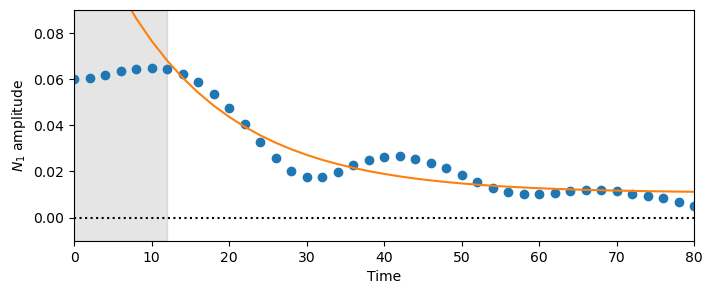

In [62]:
fig, ax = plt.subplots(figsize=(8,3))

ax.axvspan(times[0], times[first], color='k', alpha=0.10)
ax.axvspan(times[last], times[-1], color='k', alpha=0.10)
ax.plot([times[0], times[-1]], [0, 0], color='k', linestyle=':')
ax.plot(times, n1_far, marker="o", color=colors[0], ls="None")
ax.plot(times, n1_fit, color=colors[1])

# ax.text(60, 0.9*np.max(n1_fit), '$\\gamma_{{Landau}}$ : {:.4f}'.format(gamma_landau))
# ax.text(60, 0.8*np.max(n1_fit), '$\\gamma_{{PHARE}}$ : {:.4f}'.format(gamma_num))

ax.set_xlim([0, 80])
ax.set_ylim([-0.01, 0.09])
ax.set_xlabel('Time')
ax.set_ylabel('$N_1$ amplitude')